In [15]:
# https://judge.nitro-ai.org/competitions/nitro/rise-2026-open-qualifier-2/2/view

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython import display
import string

from scipy.io import wavfile
import scipy.signal as signal

import random
import torch
from torch import nn
import torch.nn.functional as F

def seed_everything(seed=20260322):
 random.seed(seed)
 os.environ['PYTHONHASHSEED'] = str(seed)
 np.random.seed(seed)

 try:
     torch.manual_seed(seed)
     torch.cuda.manual_seed(seed)
     torch.cuda.manual_seed_all(seed)
     torch.backends.cudnn.deterministic = True
     torch.backends.cudnn.benchmark = False
 except NameError:
     pass

seed_everything(20260322)

In [16]:
train = pd.read_csv("/kaggle/input/datasets/abukanabek/digit-tags/train_data/train_data.csv")
test = pd.read_csv("/kaggle/input/datasets/abukanabek/digit-tags/test_data/test_data.csv")
subm = pd.read_csv("/kaggle/input/datasets/abukanabek/digit-tags/sample_output.csv")

train.shape, test.shape, subm.shape

((300, 3), (200, 2), (200, 3))

In [17]:
train.head()

,subtaskID,datapointID,answer
0,1,0,|967153686617|
1,1,1,|475237568072|
2,1,2,|554532815990|
3,1,3,|62700892530689|
4,1,4,|2065995398890|


In [18]:
def get_spectrogram(wav_path):
    sr, data = wavfile.read(wav_path)                                       # Reading the data from the given path
    _, _, Sxx = signal.spectrogram(data, sr, nperseg = 1024, noverlap = 500)# Computing the standard linear spectrogram
    Sxx = 10 * np.log10(Sxx + 1e-10)                                        # Transforming the spectrogram in logarithmic scale
    plt.matshow(Sxx)                                                        # Plotting the spectrogram using matplotlib
    plt.show()

def get_waveform(wav_path):
    sr, data = wavfile.read(wav_path)                                       # Reading the data from the given path
    plt.figure(figsize=(10, 7))
    plt.plot(data)                                                          # Plotting the waveforms using matplotlib
    plt.show()
    display.display(display.Audio(wav_path))
    return data, sr

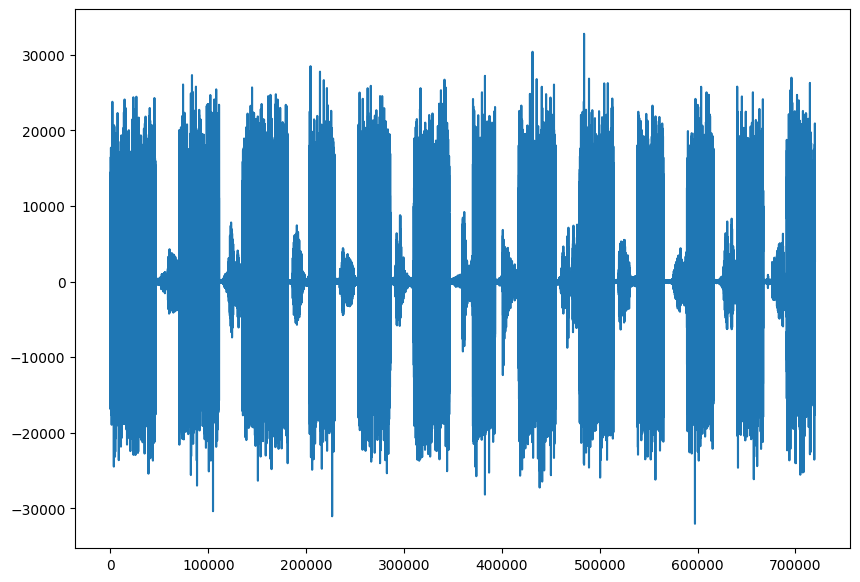

In [19]:
data, sr = get_waveform("/kaggle/input/datasets/abukanabek/digit-tags/train_data/train/1.wav")

In [20]:
# Use a pipeline as a high-level helper
from transformers import pipeline

pipe = pipeline("automatic-speech-recognition", model="openai/whisper-large-v3", chunk_length_s=30)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1259 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

normalizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/340 [00:00<?, ?B/s]

Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


In [21]:
pipe("/kaggle/input/datasets/abukanabek/digit-tags/train_data/train/0.wav")

{'text': ' Nine. Six. Seven. One. Five. Three. Six. Eight. Six. Six. One. Seven. Eight.'}

In [22]:
word2dig = {
    'zero': 0,
    'one': 1,
    'two': 2,
    'three': 3,
    'four': 4,
    'five': 5,
    'six': 6,
    'seven': 7,
    'eight': 8,
    'nine': 9
}

In [23]:
texts = []

for idx in tqdm(test['datapointID']):
    txt = pipe(f"/kaggle/input/datasets/abukanabek/digit-tags/test_data/test/{idx}.wav")['text']
    texts.append(txt)

len(texts)

  0%|          | 0/200 [00:00<?, ?it/s]

200

In [24]:
translator = str.maketrans('', '', string.punctuation)

def remove_punct(text):
    return text.translate(translator)

In [25]:
for i in range(200):
    texts[i] = remove_punct(texts[i]).lower()

In [26]:
texts[:10]

[' four four one seven two one three three one three eight nine',
 ' nine eight six five three nine three six seven zero eight zero nine',
 ' two three six six nine eight zero one eight zero two two zero',
 ' six three seven six three four three zero zero eight five six',
 ' three zero nine five four one four one three three three zero',
 ' seven zero five six six nine eight four five zero nine three eight nine',
 ' eight zero two eight nine one six six six zero two five six',
 ' one zero seven four one two nine one six five zero two one',
 ' five six seven seven two three four zero eight two five one four five',
 ' four zero five six two three two two zero six two seven']

In [27]:
answers = []

for txt in texts:
    if not any([str(i) in txt for i in range(10)]):
        digits = ''.join(list(map(str, list(map(word2dig.get, txt.strip().split())))))
    else:
        digits = ''.join(txt.strip().split())
    digits = '|' + digits + '|'
    answers.append(digits)

answers[:10]

['|441721331389|',
 '|9865393670809|',
 '|2366980180220|',
 '|637634300856|',
 '|309541413330|',
 '|70566984509389|',
 '|8028916660256|',
 '|1074129165021|',
 '|56772340825145|',
 '|405623220627|']

In [28]:
subm['answer'] = answers

subm.to_csv("submission.csv", index=False)

subm.head()

,subtaskID,datapointID,answer
0,1,0,|441721331389|
1,1,1,|9865393670809|
2,1,2,|2366980180220|
3,1,3,|637634300856|
4,1,4,|309541413330|
